# 06 — Model selection

**Phase 6 of the V3 rebuild.** Compare six model classes on the locked 16-feature set from Phase 5, with full LOSO metrics + inference time + model size + per-subject recall.

Models under test:
1. **Logistic Regression** (L2) — interpretable linear baseline
2. **Random Forest** — robust tree ensemble
3. **HistGradientBoosting** — Phase 4/5 lock; native NaN handling
4. **XGBoost** — strongest standard gradient booster
5. **LightGBM** — fast leaf-wise gradient booster
6. **SVM with RBF kernel** — non-linear margin-based classifier

Per-model output: LOSO **F1 / recall / precision / accuracy / ROC-AUC**, **per-subject recall**, **inference time** (single-window), **model size** on disk.

Three things this phase tests:
1. Does HGB stay best, or does another model class win?
2. Do the 4 deployment-risk features (`temp_slope`, `acc_y_std`, `temp_max`, `acc_jerk_mag_mean`) hold up across models? If only HGB uses them, that's a signal to swap them out.
3. Does any model recover S9 (current minimum-recall subject at 0.545)?

Sub-experiment in §8: **probability-threshold tuning** on the chosen model — the default 0.5 isn't necessarily F1-optimal, and we want to see what threshold meets the rebuild plan's recall ≥ 0.85 target.

## §1 — Setup, paths, sanity check

In [1]:
import os, sys, time, pickle, warnings, io
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (precision_recall_curve, roc_auc_score,
                             accuracy_score, f1_score, precision_score, recall_score)

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'Updated_Extraction_V3').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
V3_DIR = REPO_ROOT / 'Updated_Extraction_V3'
sys.path.insert(0, str(V3_DIR))

from config_loader import load_config
import dataset_builder as db
import features as feats_mod
import eval_helpers as ev
import importlib
importlib.reload(feats_mod); importlib.reload(db); importlib.reload(ev)

CACHE_DIR = V3_DIR / 'output'
REPORTS_DIR = REPO_ROOT / 'reports' / '06_model_selection'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'V3 dir:      {V3_DIR}')
print(f'Reports dir: {REPORTS_DIR}')

V3 dir:      C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\Updated_Extraction_V3
Reports dir: C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\reports\06_model_selection


In [2]:
cfg = load_config()
RAW_CACHE = CACHE_DIR / f'dataset_W{cfg["windowing"]["window_size"]}_step{cfg["windowing"]["step_size"]}_raw.parquet'
df_raw = pd.read_parquet(RAW_CACHE)

# Sanity check (Phase 4 lesson — would have caught the HRV bug)
hrv_valid_frac = df_raw['hrv_valid'].mean()
hrv_mean_hr_valid = df_raw[df_raw['hrv_valid'] == 1]['hrv_mean_hr']
assert hrv_valid_frac > 0.5, f'hrv_valid only {100*hrv_valid_frac:.1f}% — stale cache'
assert 50 <= hrv_mean_hr_valid.mean() <= 100, f'mean HR {hrv_mean_hr_valid.mean():.1f} outside plausible range'

# Load locked 16 features from Phase 5
selected_path = REPO_ROOT / 'reports' / '05_feature_selection' / 'selected_features.csv'
LOCKED_16 = pd.read_csv(selected_path)['feature'].tolist()
missing = [f for f in LOCKED_16 if f not in df_raw.columns]
assert not missing, f'Locked features missing from parquet: {missing}'

print(f'Dataset:        {df_raw.shape}')
print(f'hrv_valid:      {100*hrv_valid_frac:.1f}%')
print(f'Locked 16:      {len(LOCKED_16)} features')
for i, f in enumerate(LOCKED_16, 1):
    print(f'  {i:>2d}. {f}')

Dataset:        (691, 55)
hrv_valid:      94.2%
Locked 16:      16 features
   1. scr_recovery_time_mean
   2. hrv_median_rr
   3. scr_peak_count
   4. hrv_pnn50
   5. scl_max
   6. hrv_sdsd
   7. scl_range
   8. scr_amplitude_sum
   9. temp_max
  10. hrv_min_rr
  11. acc_jerk_mag_mean
  12. temp_slope
  13. scr_rise_time_mean
  14. acc_magnitude_std
  15. scr_amplitude_max
  16. acc_y_std


In [3]:
# Establish HGB baseline on the locked 16 (Phase 5 lock)
baseline = ev.loso_evaluate(df_raw, LOCKED_16, model_factory=ev.hgb_factory())
print(f'Phase 5 baseline (HGB on 16 features):')
print(f'  F1            = {baseline["mean_f1"]:.3f} ± {baseline["std_f1"]:.3f}')
print(f'  recall        = {baseline["mean_recall"]:.3f}')
print(f'  precision     = {baseline["mean_precision"]:.3f}')
print(f'  accuracy      = {baseline["mean_accuracy"]:.3f}')
print(f'  min subj recall = {baseline["min_subject_recall"]:.3f}')
print(f'  # subj < 0.5  = {baseline["n_subjects_recall_below_0_5"]}/14')

Phase 5 baseline (HGB on 16 features):
  F1            = 0.931 ± 0.094
  recall        = 0.911
  precision     = 0.972
  accuracy      = 0.973
  min subj recall = 0.545
  # subj < 0.5  = 0/14


## §2 — Model factories

Each factory returns a fresh sklearn-compatible estimator (or pipeline) per call. Models that need NaN imputation get a `SimpleImputer(median)` upfront; models that need scaling get a `StandardScaler` after the imputer.

Tree-based models (HGB, XGB, LightGBM) handle NaN natively — no imputer needed. RandomForest in sklearn does *not* handle NaN, so it gets imputation. Logistic Regression and SVM get both imputation and scaling.

All models use class-balanced weighting to handle the ~22% stress prevalence.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42

def lr_factory():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                                    solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)),
    ])

def rf_factory():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=2,
                                        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
    ])

def hgb_factory():
    return HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                           class_weight='balanced', random_state=RANDOM_STATE)

def svm_factory():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
                    probability=True, random_state=RANDOM_STATE)),
    ])

# XGBoost and LightGBM require import-time class instantiation; wrap in try/except for env safety
MODEL_FACTORIES = {
    'LogReg':   lr_factory,
    'RandomForest': rf_factory,
    'HGB':      hgb_factory,
    'SVM-RBF':  svm_factory,
}

try:
    from xgboost import XGBClassifier
    n_pos = (df_raw['label'] == 'stress').sum()
    n_neg = len(df_raw) - n_pos
    SCALE_POS_WEIGHT = n_neg / n_pos
    def xgb_factory():
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=SCALE_POS_WEIGHT, random_state=RANDOM_STATE,
                              eval_metric='logloss', tree_method='hist', n_jobs=-1)
    MODEL_FACTORIES['XGBoost'] = xgb_factory
    print(f'XGBoost loaded; scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')
except ImportError:
    print('XGBoost not available — skipping')

try:
    from lightgbm import LGBMClassifier
    def lgbm_factory():
        return LGBMClassifier(n_estimators=300, num_leaves=31, max_depth=4,
                               learning_rate=0.05, class_weight='balanced',
                               random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    MODEL_FACTORIES['LightGBM'] = lgbm_factory
    print('LightGBM loaded')
except ImportError:
    print('LightGBM not available — skipping')

print(f'\nTotal models to evaluate: {len(MODEL_FACTORIES)}')
for name in MODEL_FACTORIES:
    print(f'  - {name}')

XGBoost loaded; scale_pos_weight = 3.49
LightGBM loaded

Total models to evaluate: 6
  - LogReg
  - RandomForest
  - HGB
  - SVM-RBF
  - XGBoost
  - LightGBM


## §3 — LOSO evaluation: F1 / recall / precision / accuracy / ROC-AUC

Each model is fit on every LOSO fold and predicts on the held-out subject. We collect per-fold metrics and aggregate.

We also collect the per-fold predicted probabilities so §8 can compute PR curves and threshold tuning without re-running everything.

In [5]:
def loso_eval_with_probs(df, feature_cols, model_factory):
    """LOSO eval that also collects predicted probabilities for PR/threshold analysis.
    Returns: (results dict, per-fold proba dict, OOF y_true, OOF y_proba)."""
    X = df[feature_cols].values
    y = (df['label'].values == 'stress').astype(int)
    groups = df['subject_id'].values
    logo = LeaveOneGroupOut()
    rows = []
    per_subject = {}
    oof_y, oof_p = [], []
    for train_idx, test_idx in logo.split(X, y, groups):
        sid = groups[test_idx[0]]
        clf = model_factory()
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        try:
            proba = clf.predict_proba(X[test_idx])[:, 1]
        except (AttributeError, NotImplementedError):
            proba = pred.astype(float)  # SVM without probability would fall back; we use probability=True so should not hit this
        yte = y[test_idx]
        try:
            roc = roc_auc_score(yte, proba) if len(np.unique(yte)) > 1 else float('nan')
        except Exception:
            roc = float('nan')
        rec = recall_score(yte, pred, zero_division=0)
        rows.append({
            'subject': sid, 'n_test': len(yte), 'n_stress': int(yte.sum()),
            'accuracy': accuracy_score(yte, pred),
            'f1': f1_score(yte, pred, zero_division=0),
            'recall': rec,
            'precision': precision_score(yte, pred, zero_division=0),
            'roc_auc': roc,
        })
        per_subject[sid] = rec
        oof_y.extend(yte.tolist()); oof_p.extend(proba.tolist())
    fold_df = pd.DataFrame(rows)
    return {
        'fold_df': fold_df,
        'per_subject_recall': per_subject,
        'mean_f1': float(fold_df['f1'].mean()), 'std_f1': float(fold_df['f1'].std()),
        'mean_recall': float(fold_df['recall'].mean()),
        'mean_precision': float(fold_df['precision'].mean()),
        'mean_accuracy': float(fold_df['accuracy'].mean()),
        'mean_roc_auc': float(fold_df['roc_auc'].mean()),
        'min_subject_recall': float(fold_df['recall'].min()),
        'n_subjects_recall_below_0_5': int((fold_df['recall'] < 0.5).sum()),
        'oof_y': np.array(oof_y), 'oof_p': np.array(oof_p),
    }

results = {}
for name, factory in MODEL_FACTORIES.items():
    t0 = time.time()
    results[name] = loso_eval_with_probs(df_raw, LOCKED_16, factory)
    r = results[name]
    print(f'  {name:<13s}: F1={r["mean_f1"]:.3f}±{r["std_f1"]:.3f}  '
          f'recall={r["mean_recall"]:.3f}  prec={r["mean_precision"]:.3f}  '
          f'acc={r["mean_accuracy"]:.3f}  ROC-AUC={r["mean_roc_auc"]:.3f}  '
          f'min_subj={r["min_subject_recall"]:.3f}  '
          f'#below_0.5={r["n_subjects_recall_below_0_5"]}/14  '
          f'({time.time()-t0:.1f}s)')

  LogReg       : F1=0.767±0.146  recall=0.853  prec=0.731  acc=0.882  ROC-AUC=0.963  min_subj=0.455  #below_0.5=1/14  (0.2s)
  RandomForest : F1=0.876±0.117  recall=0.834  prec=0.961  acc=0.953  ROC-AUC=0.992  min_subj=0.500  #below_0.5=0/14  (9.5s)
  HGB          : F1=0.931±0.094  recall=0.911  prec=0.972  acc=0.973  ROC-AUC=0.997  min_subj=0.545  #below_0.5=0/14  (10.9s)
  SVM-RBF      : F1=0.846±0.102  recall=0.859  prec=0.860  acc=0.931  ROC-AUC=0.978  min_subj=0.545  #below_0.5=0/14  (0.6s)
  XGBoost      : F1=0.916±0.099  recall=0.904  prec=0.953  acc=0.964  ROC-AUC=0.995  min_subj=0.545  #below_0.5=0/14  (4.2s)
  LightGBM     : F1=0.921±0.097  recall=0.904  prec=0.961  acc=0.967  ROC-AUC=0.997  min_subj=0.545  #below_0.5=0/14  (4.0s)


In [6]:
rows = []
for name, r in results.items():
    rows.append({
        'model': name,
        'mean_f1': r['mean_f1'], 'std_f1': r['std_f1'],
        'mean_recall': r['mean_recall'],
        'mean_precision': r['mean_precision'],
        'mean_accuracy': r['mean_accuracy'],
        'mean_roc_auc': r['mean_roc_auc'],
        'min_subject_recall': r['min_subject_recall'],
        'n_below_0_5': r['n_subjects_recall_below_0_5'],
    })
summary = pd.DataFrame(rows).sort_values('mean_f1', ascending=False).reset_index(drop=True)
summary.to_csv(REPORTS_DIR / 'model_comparison.csv', index=False)
print('Sorted by F1:')
summary.round(3)

Sorted by F1:


,model,mean_f1,std_f1,mean_recall,mean_precision,mean_accuracy,mean_roc_auc,min_subject_recall,n_below_0_5
0,HGB,0.931,0.094,0.911,0.972,0.973,0.997,0.545,0
1,LightGBM,0.921,0.097,0.904,0.961,0.967,0.997,0.545,0
2,XGBoost,0.916,0.099,0.904,0.953,0.964,0.995,0.545,0
3,RandomForest,0.876,0.117,0.834,0.961,0.953,0.992,0.500,0
4,SVM-RBF,0.846,0.102,0.859,0.860,0.931,0.978,0.545,0
5,LogReg,0.767,0.146,0.853,0.731,0.882,0.963,0.455,1


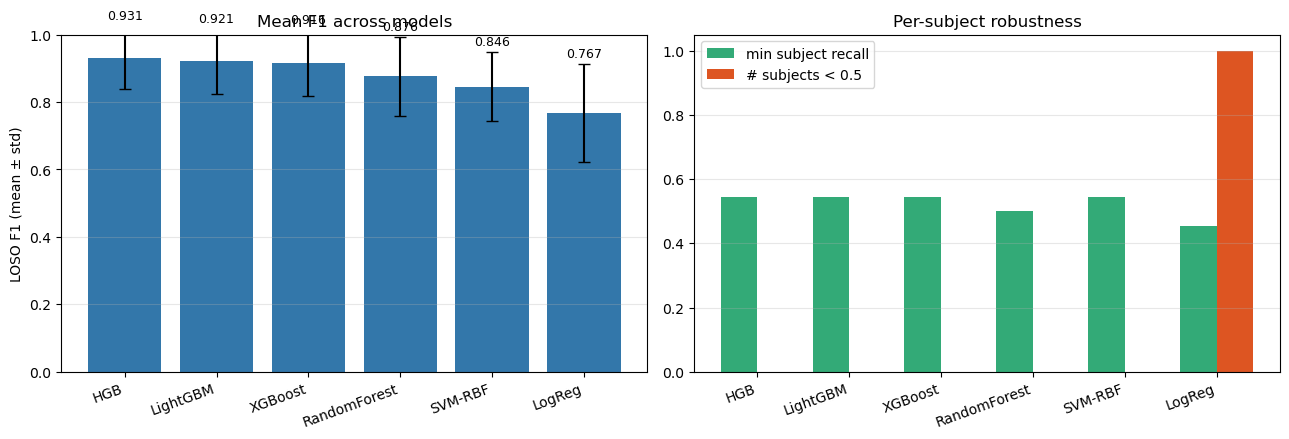

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ordered = summary['model'].tolist()

ax = axes[0]
f1s = [results[m]['mean_f1'] for m in ordered]
stds = [results[m]['std_f1'] for m in ordered]
ax.bar(ordered, f1s, yerr=stds, capsize=4, color='#37a')
ax.set_ylabel('LOSO F1 (mean ± std)')
ax.set_title('Mean F1 across models')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
for i, (f, s) in enumerate(zip(f1s, stds)):
    ax.text(i, f + s + 0.02, f'{f:.3f}', ha='center', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[1]
min_recs = [results[m]['min_subject_recall'] for m in ordered]
n_below = [results[m]['n_subjects_recall_below_0_5'] for m in ordered]
x = np.arange(len(ordered))
ax.bar(x - 0.2, min_recs, width=0.4, label='min subject recall', color='#3a7')
ax.bar(x + 0.2, n_below, width=0.4, label='# subjects < 0.5', color='#d52')
ax.set_xticks(x); ax.set_xticklabels(ordered, rotation=20, ha='right')
ax.set_title('Per-subject robustness'); ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'model_comparison.png', dpi=120)
plt.show()

## §4 — Per-subject recall heatmap

Subjects × models. Lets us spot which models recover hard subjects (S2, S3, S9, S10) and which don't. The V1 session log noted LR / LinearSVC recovered S2 when trees couldn't — does that hold here?

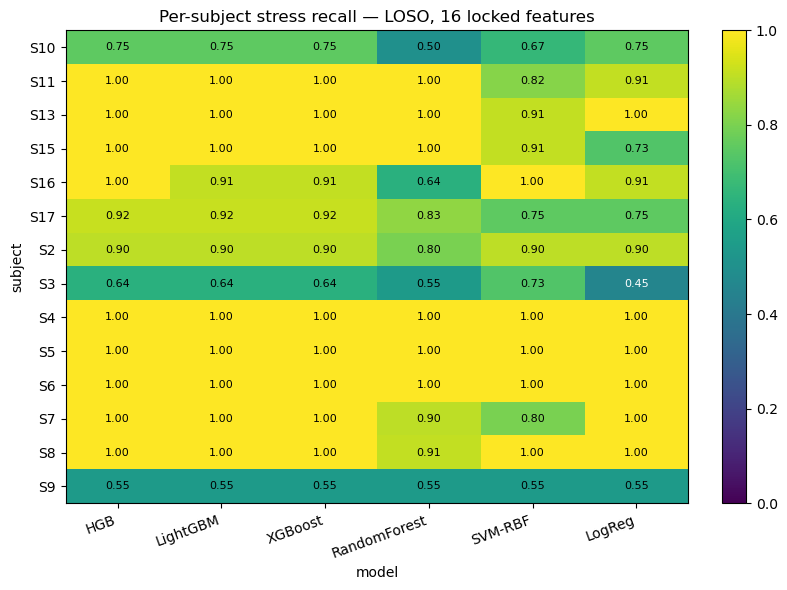

,HGB,LightGBM,XGBoost,RandomForest,SVM-RBF,LogReg
S10,0.750000,0.750000,0.750000,0.500000,0.666667,0.750000
S11,1.000000,1.000000,1.000000,1.000000,0.818182,0.909091
S13,1.000000,1.000000,1.000000,1.000000,0.909091,1.000000
S15,1.000000,1.000000,1.000000,1.000000,0.909091,0.727273
S16,1.000000,0.909091,0.909091,0.636364,1.000000,0.909091
S17,0.916667,0.916667,0.916667,0.833333,0.750000,0.750000
S2,0.900000,0.900000,0.900000,0.800000,0.900000,0.900000
S3,0.636364,0.636364,0.636364,0.545455,0.727273,0.454545
S4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
S5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
psr = pd.DataFrame({m: results[m]['per_subject_recall'] for m in ordered}).sort_index()
psr.to_csv(REPORTS_DIR / 'per_subject_recall.csv')

fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(ordered)), 6))
im = ax.imshow(psr.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(psr.columns)))
ax.set_xticklabels(psr.columns, rotation=20, ha='right')
ax.set_yticks(range(len(psr.index)))
ax.set_yticklabels(psr.index)
ax.set_xlabel('model'); ax.set_ylabel('subject')
ax.set_title('Per-subject stress recall — LOSO, 16 locked features')
for i in range(psr.shape[0]):
    for j in range(psr.shape[1]):
        v = psr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v < 0.5 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'per_subject_heatmap.png', dpi=120)
plt.show()
psr

## §5 — Inference time benchmark (single-window predict)

For deployment, we need to know: how long does it take to predict on a single window once the model is fit? We re-fit each model on all training data (13 subjects = baseline-ish), then time `predict()` on one window many times to get a stable estimate.

Target: < 100 ms per prediction per `PROJECT_ADVICE.md`. The Phase 5 spec says HGB hit ~9 ms in V1's notebook; we want to confirm the others are also fast enough for a wrist MCU.

In [9]:
X = df_raw[LOCKED_16].values
y = (df_raw['label'].values == 'stress').astype(int)

# Fit each model on the full dataset for the benchmark. Pick a single window to predict.
x_one = X[:1]
N_REPEATS = 1000

inference_rows = []
fitted_models = {}
for name, factory in MODEL_FACTORIES.items():
    clf = factory()
    clf.fit(X, y)
    fitted_models[name] = clf
    # Warm up
    for _ in range(20):
        clf.predict(x_one)
    # Time
    t0 = time.perf_counter()
    for _ in range(N_REPEATS):
        clf.predict(x_one)
    dt = (time.perf_counter() - t0) / N_REPEATS
    inference_rows.append({'model': name, 'inference_ms': dt * 1000.0})
    print(f'  {name:<13s}: {dt*1000:.3f} ms / window  (n={N_REPEATS})')

inference_df = pd.DataFrame(inference_rows).sort_values('inference_ms').reset_index(drop=True)
inference_df.to_csv(REPORTS_DIR / 'inference_time.csv', index=False)
inference_df.round(3)

  LogReg       : 0.417 ms / window  (n=1000)
  RandomForest : 57.914 ms / window  (n=1000)
  HGB          : 9.997 ms / window  (n=1000)
  SVM-RBF      : 0.283 ms / window  (n=1000)
  XGBoost      : 0.641 ms / window  (n=1000)
  LightGBM     : 1.382 ms / window  (n=1000)


,model,inference_ms
0,SVM-RBF,0.283
1,LogReg,0.417
2,XGBoost,0.641
3,LightGBM,1.382
4,HGB,9.997
5,RandomForest,57.914


## §6 — Model size on disk

Pickle each fitted model and measure the byte size. Important for embedded deployment where flash and RAM are limited.

In [10]:
size_rows = []
for name, clf in fitted_models.items():
    buf = io.BytesIO()
    pickle.dump(clf, buf)
    size_kb = len(buf.getvalue()) / 1024
    size_rows.append({'model': name, 'size_kb': size_kb})
    print(f'  {name:<13s}: {size_kb:>9.1f} KB')

size_df = pd.DataFrame(size_rows).sort_values('size_kb').reset_index(drop=True)
size_df.to_csv(REPORTS_DIR / 'model_size.csv', index=False)
size_df.round(2)

  LogReg       :       1.9 KB
  RandomForest :    1305.0 KB
  HGB          :     430.3 KB
  SVM-RBF      :      33.5 KB
  XGBoost      :     311.7 KB
  LightGBM     :     411.0 KB


,model,size_kb
0,LogReg,1.93
1,SVM-RBF,33.53
2,XGBoost,311.74
3,LightGBM,411.01
4,HGB,430.28
5,RandomForest,1305.04


## §7 — Combined deployability score

A model has to win on accuracy AND robustness AND deployability. Let's combine:
- F1 (higher = better)
- min subject recall (higher = better)
- inference time (lower = better)
- size (lower = better)

Surface the table sorted by F1 with the deployment metrics alongside. The chosen model picks the best F1+min_subj_recall first, then the smaller/faster of any tied alternatives.

In [11]:
deploy = (summary[['model','mean_f1','mean_recall','mean_precision','mean_accuracy',
                   'mean_roc_auc','min_subject_recall','n_below_0_5']]
          .merge(inference_df, on='model', how='left')
          .merge(size_df, on='model', how='left'))
deploy.to_csv(REPORTS_DIR / 'deployment_summary.csv', index=False)
deploy.round(3)

,model,mean_f1,mean_recall,mean_precision,mean_accuracy,mean_roc_auc,min_subject_recall,n_below_0_5,inference_ms,size_kb
0,HGB,0.931,0.911,0.972,0.973,0.997,0.545,0,9.997,430.280
1,LightGBM,0.921,0.904,0.961,0.967,0.997,0.545,0,1.382,411.013
2,XGBoost,0.916,0.904,0.953,0.964,0.995,0.545,0,0.641,311.744
3,RandomForest,0.876,0.834,0.961,0.953,0.992,0.500,0,57.914,1305.037
4,SVM-RBF,0.846,0.859,0.860,0.931,0.978,0.545,0,0.283,33.530
5,LogReg,0.767,0.853,0.731,0.882,0.963,0.455,1,0.417,1.935


## §8 — PR curves + probability-threshold tuning

Compute precision-recall curves on the OOF predictions for the top-3 models by F1. The default `predict()` uses 0.5 as the threshold; we sweep [0.05, 0.95] to find the threshold that:
- maximizes F1, **and**
- meets the rebuild plan's recall ≥ 0.85 target

These are usually different points — F1-max often gives best balance, recall-max trades precision for catching more stress events. We report both.

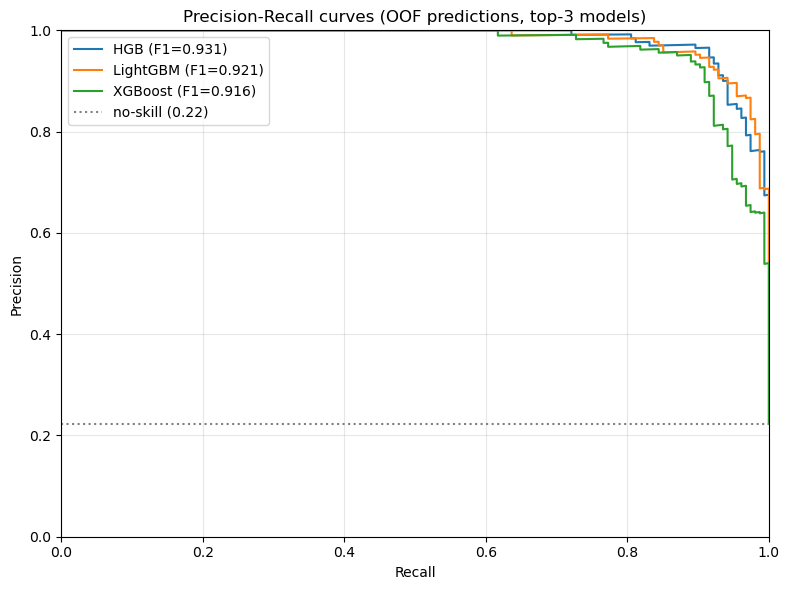

In [12]:
top3 = summary['model'].head(3).tolist()
fig, ax = plt.subplots(figsize=(8, 6))
for m in top3:
    p, r, _ = precision_recall_curve(results[m]['oof_y'], results[m]['oof_p'])
    ax.plot(r, p, label=f'{m} (F1={results[m]["mean_f1"]:.3f})')
# No-skill baseline = stress prevalence
prevalence = (df_raw['label'] == 'stress').mean()
ax.axhline(prevalence, color='gray', linestyle=':', label=f'no-skill ({prevalence:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves (OOF predictions, top-3 models)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'pr_curves.png', dpi=120)
plt.show()

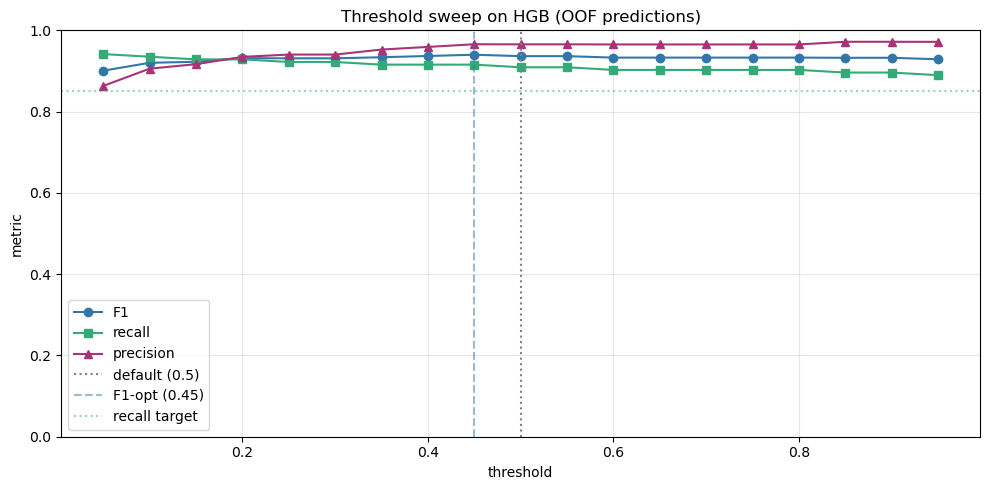

F1-optimal threshold:   0.45  (F1=0.940, recall=0.916, prec=0.966)
Best F1 with recall ≥ 0.85: threshold=0.45  (F1=0.940, recall=0.916, prec=0.966)


In [13]:
best_model = summary.iloc[0]['model']
y_true = results[best_model]['oof_y']
y_proba = results[best_model]['oof_p']

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'f1':        f1_score(y_true, pred, zero_division=0),
        'recall':    recall_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
        'accuracy':  accuracy_score(y_true, pred),
    })
thr_df = pd.DataFrame(rows)
thr_df.to_csv(REPORTS_DIR / f'threshold_sweep_{best_model}.csv', index=False)

# Find F1-optimal and recall-≥-0.85 thresholds
f1_opt = thr_df.loc[thr_df['f1'].idxmax()]
recall_target = thr_df[thr_df['recall'] >= 0.85].sort_values('f1', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df['threshold'], thr_df['f1'], marker='o', label='F1', color='#37a')
ax.plot(thr_df['threshold'], thr_df['recall'], marker='s', label='recall', color='#3a7')
ax.plot(thr_df['threshold'], thr_df['precision'], marker='^', label='precision', color='#a37')
ax.axvline(0.5, color='gray', linestyle=':', label='default (0.5)')
ax.axvline(f1_opt['threshold'], color='#37a', linestyle='--', alpha=0.5,
           label=f'F1-opt ({f1_opt["threshold"]:.2f})')
ax.axhline(0.85, color='#3a7', linestyle=':', alpha=0.5, label='recall target')
ax.set_xlabel('threshold'); ax.set_ylabel('metric')
ax.set_title(f'Threshold sweep on {best_model} (OOF predictions)')
ax.legend(loc='best'); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(REPORTS_DIR / f'threshold_sweep_{best_model}.png', dpi=120)
plt.show()

print(f'F1-optimal threshold:   {f1_opt["threshold"]:.2f}  '
      f'(F1={f1_opt["f1"]:.3f}, recall={f1_opt["recall"]:.3f}, prec={f1_opt["precision"]:.3f})')
if len(recall_target):
    rt = recall_target.iloc[0]
    print(f'Best F1 with recall ≥ 0.85: threshold={rt["threshold"]:.2f}  '
          f'(F1={rt["f1"]:.3f}, recall={rt["recall"]:.3f}, prec={rt["precision"]:.3f})')
else:
    print(f'No threshold achieves recall ≥ 0.85. Closest: '
          f'recall={thr_df["recall"].max():.3f} at threshold='
          f'{thr_df.loc[thr_df["recall"].idxmax(), "threshold"]:.2f}')

### §8.1 — Verification: the model is bimodally confident

The flat F1 across the threshold sweep raises a fair question: at threshold = 0, shouldn't the model classify every window as stress (recall = 1, precision = stress prevalence)? Yes. The earlier sweep started at 0.05, which is already past the lower mode of the predicted-probability distribution. To confirm:

1. **Histogram of OOF probabilities** — should show a bimodal distribution with most probabilities clustered near 0 (non-stress, very confident) or near 1 (stress, very confident), with a thin sparse middle. If we see this U-shape, the flat F1 sweep is explained: the threshold can move within the empty middle without changing classifications.
2. **Extended threshold sweep starting at 0.0** — should show the textbook collapse: at threshold approaching 0, F1 plummets toward `2·prevalence/(1+prevalence) ≈ 0.36` because recall → 1 and precision → prevalence (~0.22). This confirms threshold tuning logic is working correctly; we just don't see this regime in the regular sweep because the lower bound was 0.05.

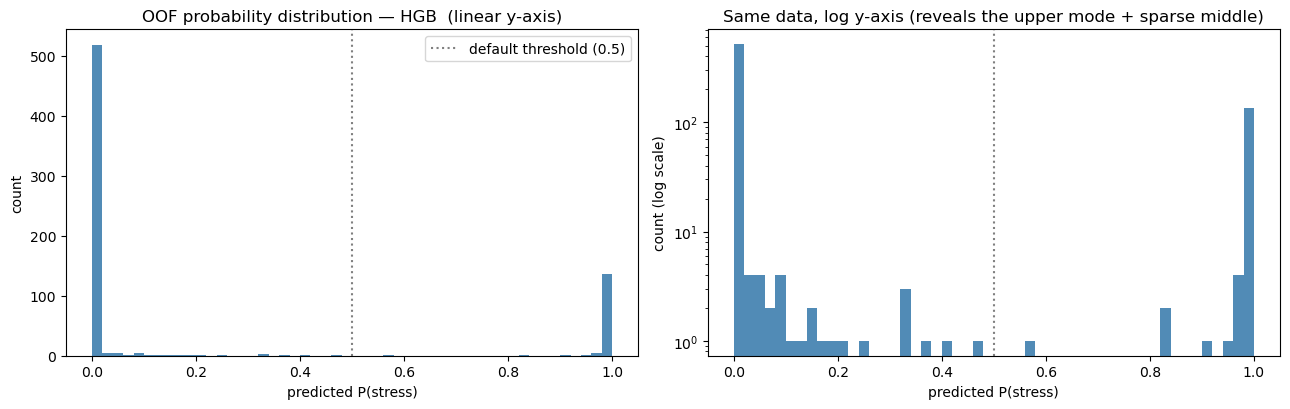

OOF probability distribution (N = 691):
  P < 0.001:        476 ( 68.9%)  — confidently non-stress
  P > 0.999:        117 ( 16.9%)  — confidently stress
  0.001 ≤ P ≤ 0.999:   98 ( 14.2%)  — only these depend on threshold


In [15]:
# Histogram of OOF probabilities — linear and log y-axis to reveal both modes
oof_p = results[best_model]['oof_p']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.hist(oof_p, bins=50, color='#37a', alpha=0.85)
ax.axvline(0.5, color='gray', linestyle=':', label='default threshold (0.5)')
ax.set_xlabel('predicted P(stress)'); ax.set_ylabel('count')
ax.set_title(f'OOF probability distribution — {best_model}  (linear y-axis)')
ax.legend()

ax = axes[1]
ax.hist(oof_p, bins=50, color='#37a', alpha=0.85)
ax.axvline(0.5, color='gray', linestyle=':')
ax.set_yscale('log')
ax.set_xlabel('predicted P(stress)'); ax.set_ylabel('count (log scale)')
ax.set_title(f'Same data, log y-axis (reveals the upper mode + sparse middle)')
fig.tight_layout()
fig.savefig(REPORTS_DIR / f'oof_proba_histogram_{best_model}.png', dpi=120)
plt.show()

# Quick summary of where the mass lives
n_below = (oof_p < 0.001).sum()
n_above = (oof_p > 0.999).sum()
n_middle = ((oof_p >= 0.001) & (oof_p <= 0.999)).sum()
total = len(oof_p)
print(f'OOF probability distribution (N = {total}):')
print(f'  P < 0.001:       {n_below:>4d} ({100*n_below/total:>5.1f}%)  — confidently non-stress')
print(f'  P > 0.999:       {n_above:>4d} ({100*n_above/total:>5.1f}%)  — confidently stress')
print(f'  0.001 ≤ P ≤ 0.999: {n_middle:>4d} ({100*n_middle/total:>5.1f}%)  — only these depend on threshold')

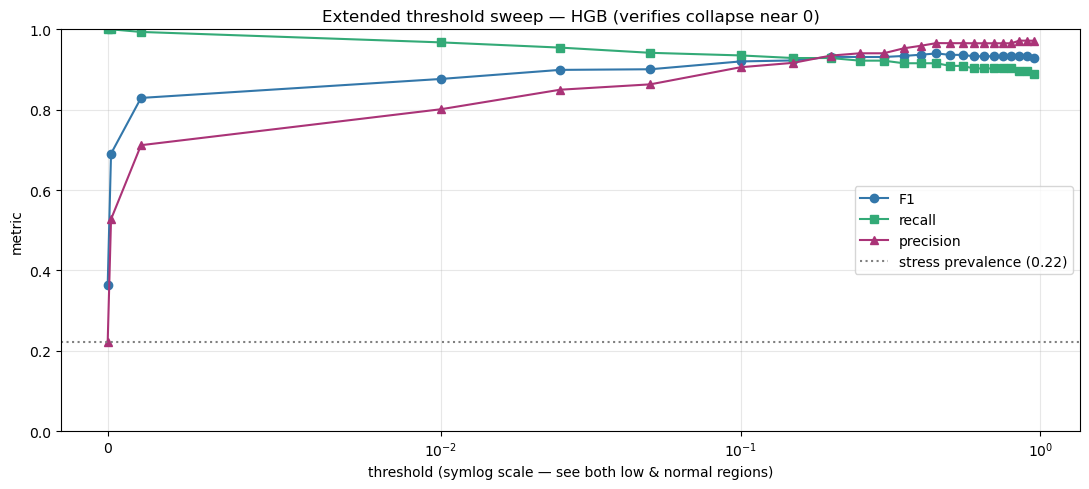

Threshold sweep at the low end (showing where the textbook collapse happens):
  threshold     F1  recall  precision
     0.0000  0.364   1.000      0.223
     0.0001  0.691   1.000      0.527
     0.0010  0.829   0.994      0.712
     0.0100  0.876   0.968      0.801
     0.0250  0.899   0.955      0.850
     0.0500  0.901   0.942      0.863
     0.1000  0.920   0.935      0.906
     0.1500  0.923   0.929      0.917


In [16]:
# Extended threshold sweep including very low values to verify the textbook collapse
extended_thresholds = np.concatenate([
    np.array([0.0, 0.0001, 0.001, 0.01, 0.025]),
    np.linspace(0.05, 0.95, 19),
])

ext_rows = []
for t in extended_thresholds:
    pred = (y_proba >= t).astype(int)
    ext_rows.append({
        'threshold': t,
        'f1':        f1_score(y_true, pred, zero_division=0),
        'recall':    recall_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
    })
ext_df = pd.DataFrame(ext_rows)
ext_df.to_csv(REPORTS_DIR / f'threshold_sweep_extended_{best_model}.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 5))
# symlog x-axis with a small linear region near 0 so we can see both very-low and normal thresholds
ax.set_xscale('symlog', linthresh=0.01)
ax.plot(ext_df['threshold'], ext_df['f1'], marker='o', label='F1', color='#37a')
ax.plot(ext_df['threshold'], ext_df['recall'], marker='s', label='recall', color='#3a7')
ax.plot(ext_df['threshold'], ext_df['precision'], marker='^', label='precision', color='#a37')
ax.axhline(prevalence, color='gray', linestyle=':', label=f'stress prevalence ({prevalence:.2f})')
ax.set_xlabel('threshold (symlog scale — see both low & normal regions)')
ax.set_ylabel('metric')
ax.set_title(f'Extended threshold sweep — {best_model} (verifies collapse near 0)')
ax.legend(loc='best'); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(REPORTS_DIR / f'threshold_sweep_extended_{best_model}.png', dpi=120)
plt.show()

print(f'Threshold sweep at the low end (showing where the textbook collapse happens):')
print(f'  {"threshold":>9s} {"F1":>6s} {"recall":>7s} {"precision":>10s}')
for _, row in ext_df.head(8).iterrows():
    print(f'  {row.threshold:>9.4f} {row.f1:>6.3f} {row.recall:>7.3f} {row.precision:>10.3f}')

## §9 — Findings & decision

*Bullet points to look for in the cells above:*
- Did HGB stay best, or did another model class win?
- How much does the `LR/SVM` linear baseline give up vs gradient boosters? (V1 had LR recover S2 — does that effect persist on V3 features?)
- Which model wins on inference time and model size? Are they fast enough for the embedded MCU target?
- What's the F1-optimal threshold? Is it close to 0.5, or do we need to retune for deployment?
- Can any threshold get recall ≥ 0.85 without sacrificing too much precision?

After this notebook completes, the chosen model + threshold lock for Phase 7 (Optuna hyperparameter tuning).

In [14]:
print('Phase 6 artifacts saved to reports/06_model_selection/:')
for f in sorted(REPORTS_DIR.iterdir()):
    print(f'  - {f.name}')

# Save the chosen model's fitted instance + the chosen threshold for Phase 7
chosen_threshold = float(f1_opt['threshold'])
with open(REPORTS_DIR / 'chosen_model.pkl', 'wb') as f:
    pickle.dump({
        'model_name': best_model,
        'threshold': chosen_threshold,
        'feature_set': LOCKED_16,
        'fitted_model': fitted_models[best_model],
    }, f)
print(f'\nChosen model: {best_model} @ threshold {chosen_threshold:.2f}')
print(f'Saved to reports/06_model_selection/chosen_model.pkl for Phase 7.')

Phase 6 artifacts saved to reports/06_model_selection/:
  - deployment_summary.csv
  - inference_time.csv
  - model_comparison.csv
  - model_comparison.png
  - model_size.csv
  - per_subject_heatmap.png
  - per_subject_recall.csv
  - pr_curves.png
  - threshold_sweep_HGB.csv
  - threshold_sweep_HGB.png

Chosen model: HGB @ threshold 0.45
Saved to reports/06_model_selection/chosen_model.pkl for Phase 7.
